# Efficiency and Fairness per model

In [25]:
import sys
sys.path.append('../src')

import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from bayes_opt import BayesianOptimization

from Classes.bar import Bar
from Config.config import PATHS
from Utils.utils import GetMeasurements
from Utils.cherrypick_simulations import CherryPickEquilibria

rng = np.random.default_rng(2)

In [19]:
def plot_stability(list_of_alternations, list_of_titles, num_rounds):
	fig, axes = plt.subplots(len(list_of_alternations))
	for i, alternations in enumerate(list_of_alternations):
		# Detect number of agents
		num_agents = len(alternations[0])
		# Create bar object
		bar = Bar(
			num_agents=num_agents,
			threshold=0.5
		)
		bar.history = alternations * (num_rounds // len(alternations)) + alternations[:num_rounds % len(alternations)]
		attendance_file_name = None #'alternations.png'
		bar.render(
			ax=axes[i],
			file=attendance_file_name,
			num_rounds=len(bar.history)
		)
#		axes[i].imshow(plt.imread(attendance_file_name))
		if list_of_titles is not None:
			axes[i].set_title(list_of_titles[i])
		axes[i].axis('off')
	return fig


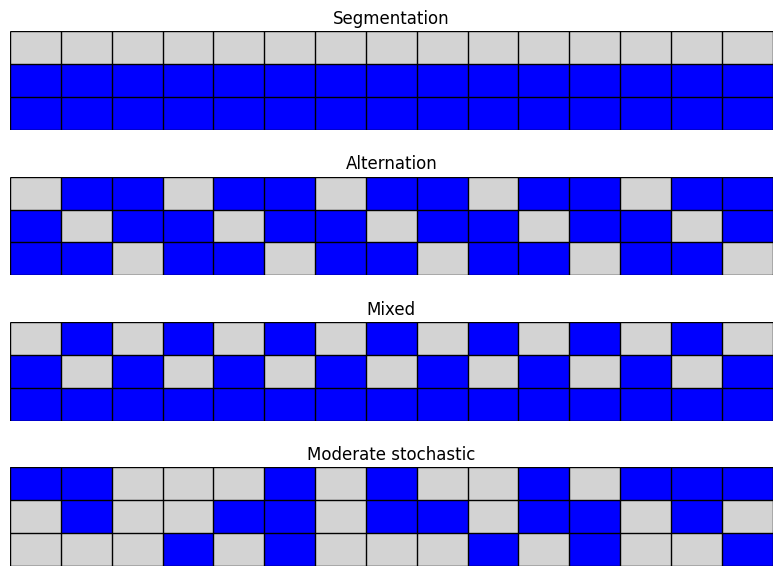

In [20]:
num_rounds = 15
list_of_alternations = [
	# [np.random.randint(0, 2, 3).tolist() for _ in range(num_rounds)],
	[[1, 1, 0]],
	[[1, 1, 0], [1, 0, 1], [0, 1, 1]],
#	[[0, 0, 1], [0, 1, 0], [1, 0, 0]],
	[[1, 1, 0], [1, 0, 1]],
    rng.choice([0, 1], size=(num_rounds, 3), p=[0.6, 0.4]).tolist(),
]
fig = plot_stability(
    list_of_alternations=list_of_alternations, 
    list_of_titles = ['Segmentation', 'Alternation', 'Mixed', 'Moderate stochastic'],
    # list_of_titles = ['Segmentation', 'Alternation', 'Mixed'],
#    list_of_titles = ['Segmentation', 'Alternation (high capacity)', 'Alternation (low capacity)', 'Mixed'],
    num_rounds=num_rounds
)
fig.tight_layout()
fig.set_size_inches(8, 6)
fig.savefig(PATHS['exploratory_figures'] / 'Coordination_types.png', dpi=300)

In [21]:
list_num_agents = [2, 4, 6, 8]
thresholds = [0.34, 0.5, 0.75]
kinds = ['alternation', 'segmentation', 'mixed', 'random', 'sober']
df_list = []
list_ids = []

for num_agents in list_num_agents:

    for threshold in thresholds:

        if threshold * num_agents < 1:
            continue

        equilibria = CherryPickEquilibria(
            num_agents=num_agents,
            threshold = threshold,
            epsilon=0,
            num_rounds=50,
            num_episodes=50,
            allow_shuffle=False,
        )

        for kind in kinds:
            if kind == 'mixed':

                if num_agents == 2:
                    continue
                if threshold * num_agents < 2:
                    continue

            df = equilibria.generate_data(kind)
            # print('')
            # print('='*60)
            # print(f"")
            # print(df[df["round"] == 1])
            this_id = df['id_sim'].unique()[0]

            if this_id not in list_ids:
                df_list.append(df)
                list_ids.append(this_id)

df = pd.concat(df_list, ignore_index=True)


Running episodes:   0%|          | 0/50 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/50 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/50 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/50 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/50 [00:00<?, ?it/s]

...

Running episodes:   0%|          | 0/50 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/50 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/50 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/50 [00:00<?, ?it/s]

Running episodes:   0%|          | 0/50 [00:00<?, ?it/s]

In [22]:
gm = GetMeasurements(
    data=df,
    measures=[
        'bounded_efficiency', 'gini_index', 
        'entropy', 'conditional_entropy', 
        'min_entropy', 'efficiency',
    ]
)
gm.columns.append('kind')
df_measures = gm.get_measurements()

In [23]:
dict_kind = {
    'random': 'Random',
    'sober': 'Sober',
    'segmentation': 'Segm.',
    'alternation': 'Alter.',
    'mixed': 'Mixed'
}
df_measures['kind'] = df_measures['kind'].map(dict_kind)

In [26]:
def binomial(k, N, p):
    a1_probs = p ** k
    a2_probs = (1-p) ** (N - k)
    combination = math.comb(N, k)
#    print(f'{combination} * {go} * {no_go}')
    return combination * a1_probs * a2_probs

def Z(p, N=10, B=6):
    sum_below_B = sum([k*binomial(k, N, p) for k in range(B+1)])
    sum_above_B = sum([k*binomial(k, N, p) for k in range(B+1, N+1)])
    return sum_below_B - sum_above_B

def get_p_star(N, B):
    # Bounded region of parameter space
    pbounds = {'p': (0, 1)}
    optimizer = BayesianOptimization(
        f=lambda p: Z(p, N, B),
        pbounds=pbounds,
        random_state=1,
        verbose=False
    )
    optimizer.maximize(
        init_points=10,
        n_iter=10,
    )
    result = optimizer.max
    return result['params']['p']

values = [(100, 50), (100, 60), (100, 70)]
p_stars = list()

for N, B in values:
	p_star = get_p_star(N, B)
	p_stars.append(p_star)

df = pd.DataFrame({
	'N': [N for N, _ in values],
	'B': [B for _, B in values],
	'mu': p_stars,
})
df['value'] = df.apply(lambda row: Z(row['mu'], int(row['N']), int(row['B'])), axis=1)
df['optimum'] = 'Pareto'

df1 = pd.DataFrame({
	'N': [N for N, _ in values],
	'B': [B for _, B in values],
	'value':[0] * len(values),
})
df1['mu'] = df1.apply(lambda row: row['B'] / row['N'], axis=1)
df1['optimum'] = 'Nash'
df = pd.concat([df, df1], ignore_index=True)


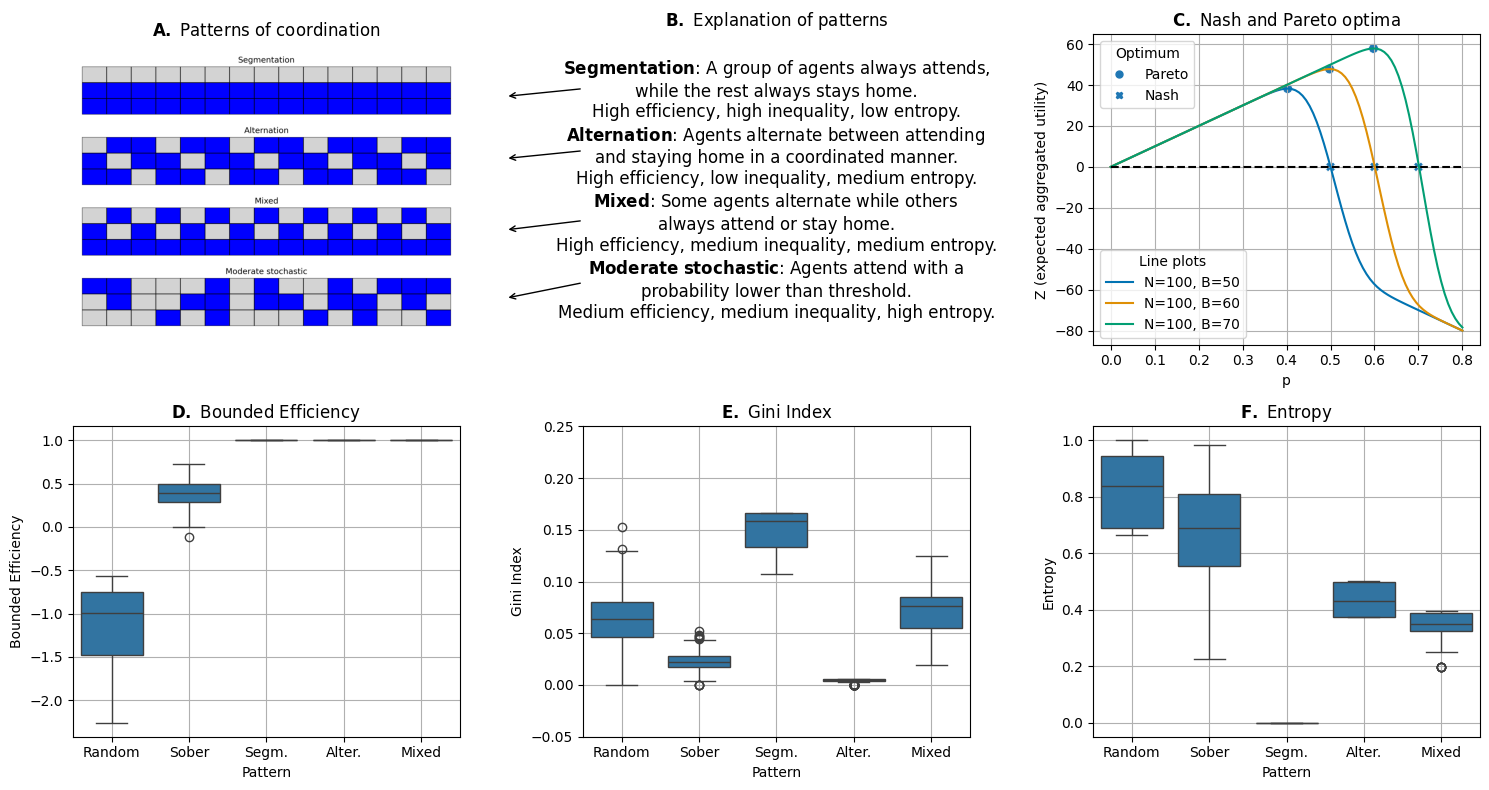

In [43]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8), tight_layout=True)

ax[0, 0].imshow(plt.imread(PATHS['exploratory_figures'] / 'Coordination_types.png'))
ax[0, 0].axis('off')
ax[0, 0].set_title(r"$\bf{A.}$ Patterns of coordination")

text = r"""
$\bf{Segmentation}$: A group of agents always attends,
while the rest always stays home.
High efficiency, high inequality, low entropy.
$\bf{Alternation}$: Agents alternate between attending 
and staying home in a coordinated manner.
High efficiency, low inequality, medium entropy.
$\bf{Mixed}$: Some agents alternate while others 
always attend or stay home.
High efficiency, medium inequality, medium entropy.
$\bf{Moderate}$ $\bf{stochastic}$: Agents attend with a 
probability lower than threshold.
Medium efficiency, medium inequality, high entropy.
"""

# Add text to the top-right subplot
ax[0, 1].text(
    0.5, 0.5,
    text,
    ha='center', va='center',
    fontsize=12
)
ax[0, 1].axis('off')
ax[0, 1].annotate(
    '',
    xy=(0.0, 0.825), xycoords='axes fraction',
    xytext=(-0.2, 0.8), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='<-'),
    fontsize=10
)
ax[0, 1].annotate(
    '',
    xy=(0.0, 0.625), xycoords='axes fraction',
    xytext=(-0.2, 0.6), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='<-'),
    fontsize=10
)
ax[0, 1].annotate(
    '',
    xy=(0.0, 0.4), xycoords='axes fraction',
    xytext=(-0.2, 0.37), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='<-'),
    fontsize=10
)
ax[0, 1].annotate(
    '',
    xy=(0.0, 0.2), xycoords='axes fraction',
    xytext=(-0.2, 0.15), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='<-'),
    fontsize=10
)
ax[0, 1].set_title(r"$\bf{B.}$ Explanation of patterns")


palette = sns.color_palette('colorblind', 6)
maximo = 0.8
N = 100

# --------------------
# LINE PLOTS
# --------------------
line_handles = []
line_labels = []

for i, mu in enumerate([0.5, 0.6, 0.7]):
    B = int(N * mu)
    X = np.linspace(0, maximo, 100)
    Y = [Z(p, N, B) for p in X]

    line, = ax[0, 2].plot(
        X,
        Y,
        color=palette[i]
    )

    line_handles.append(line)
    line_labels.append(f'N={N}, B={B}')

ax[0, 2].hlines(0, 0, maximo, color='black', linestyle='--')

legend1 = ax[0, 2].legend(
    handles=line_handles,
    labels=line_labels,
    title='Line plots',
    loc='lower left'
)

# --------------------
# SCATTER
# --------------------
scatter_palette = sns.color_palette("deep", 2)

scatter = sns.scatterplot(
    x='mu',
    y='value',
    style='optimum',
    s=50,
    data=df,
    ax=ax[0, 2],
    legend=False   # IMPORTANT
)

# Build scatter legend manually
from matplotlib.lines import Line2D

scatter_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        # color=scatter_palette[0],
        # markerfacecolor=scatter_palette[0],
        markersize=5,
        label='Pareto'
    ),
    Line2D(
        [0], [0],
        marker='X',
        linestyle='',
        # color=scatter_palette[1],
        # markerfacecolor=scatter_palette[1],
        markersize=5,
        label='Nash'
    )
]
legend2 = ax[0, 2].legend(
    handles=scatter_handles,
    title='Optimum',
    loc='upper left'
)

# Re-add first legend
ax[0, 2].add_artist(legend1)

ax[0, 2].set_xlabel('p')
ax[0, 2].set_ylabel('Z (expected aggregated utility)')
ax[0, 2].grid()
ax[0, 2].set_title(r"$\bf{C.}$ Nash and Pareto optima")


sns.boxplot(
    data=df_measures,
    x="kind",
    y="bounded_efficiency",
    ax=ax[1, 0],
    order=["Random", "Sober", "Segm.", "Alter.", "Mixed"],
)
# ax[1, 0].set_ylim(-1.5, 1.05)
ax[1, 0].set_title(r"$\bf{D.}$ Bounded Efficiency")
ax[1, 0].set_xlabel("Pattern")
ax[1, 0].set_ylabel("Bounded Efficiency")
ax[1, 0].grid()

sns.boxplot(
    data=df_measures,
    x="kind",
    y="gini_index",
    ax=ax[1, 1],
    order=["Random", "Sober", "Segm.", "Alter.", "Mixed"],
)
ax[1, 1].set_ylim(-0.05, 0.25)
ax[1, 1].set_title(r"$\bf{E.}$ Gini Index")
ax[1, 1].set_xlabel("Pattern")
ax[1, 1].set_ylabel("Gini Index")
ax[1, 1].grid()


sns.boxplot(
    data=df_measures,
    x="kind",
    y="entropy",
    ax=ax[1, 2],
    order=["Random", "Sober", "Segm.", "Alter.", "Mixed"],
)
# ax[1, 2].set_ylim(-0.05, 1.05)
ax[1, 2].set_title(r"$\bf{F.}$ Entropy")
ax[1, 2].set_xlabel("Pattern")
ax[1, 2].set_ylabel("Entropy")
ax[1, 2].grid()


plt.show()
fig.savefig(PATHS['exploratory_figures'] / 'measurements.png', dpi=300)

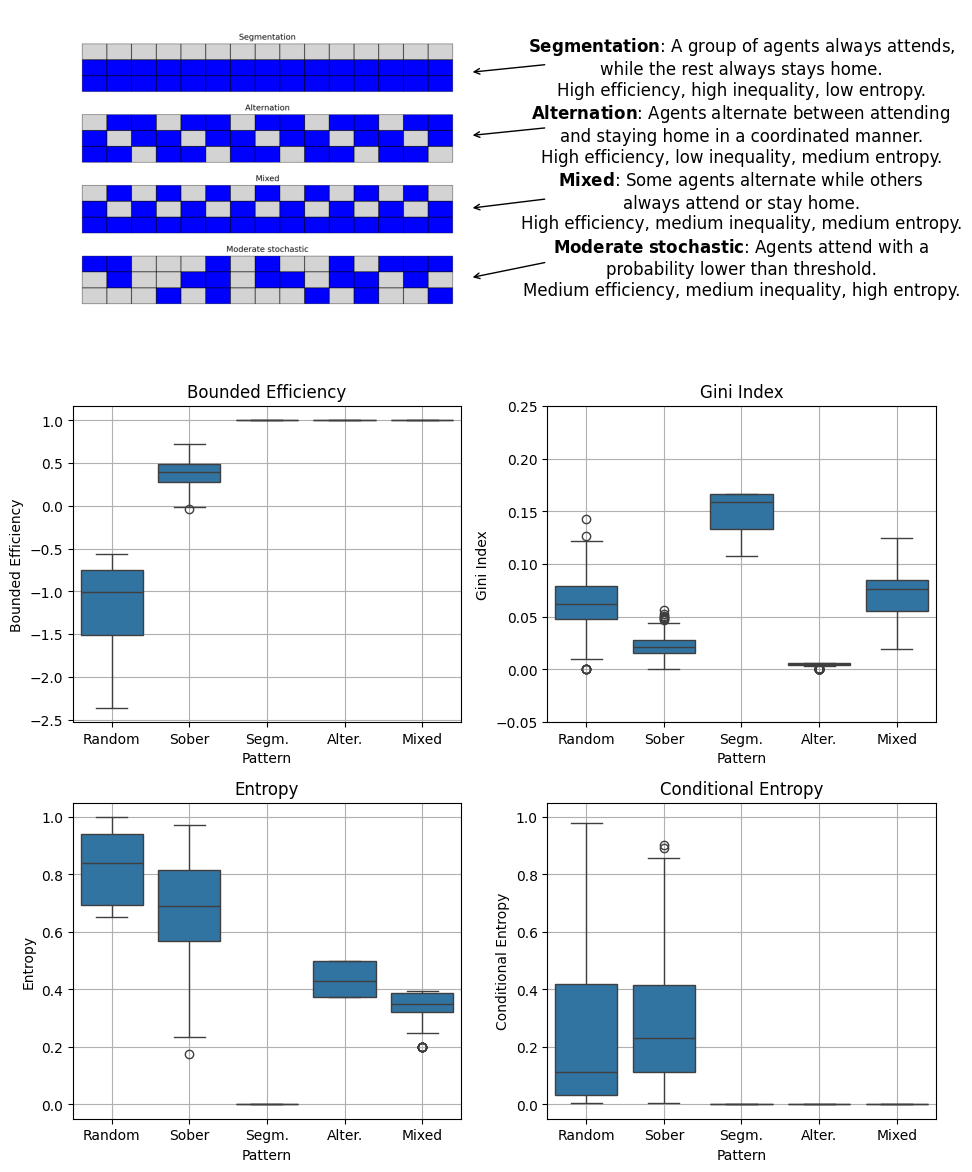

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(10, 12), tight_layout=True)

ax[0, 0].imshow(plt.imread(PATHS['exploratory_figures'] / 'Coordination_types.png'))
ax[0, 0].axis('off')

text = r"""
$\bf{Segmentation}$: A group of agents always attends,
while the rest always stays home.
High efficiency, high inequality, low entropy.
$\bf{Alternation}$: Agents alternate between attending 
and staying home in a coordinated manner.
High efficiency, low inequality, medium entropy.
$\bf{Mixed}$: Some agents alternate while others 
always attend or stay home.
High efficiency, medium inequality, medium entropy.
$\bf{Moderate}$ $\bf{stochastic}$: Agents attend with a 
probability lower than threshold.
Medium efficiency, medium inequality, high entropy.
"""

# Add text to the top-right subplot
ax[0, 1].text(
    0.5, 0.5,
    text,
    ha='center', va='center',
    fontsize=12
)
ax[0, 1].axis('off')
ax[0, 1].annotate(
    '',
    xy=(0.0, 0.825), xycoords='axes fraction',
    xytext=(-0.2, 0.8), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='<-'),
    fontsize=10
)
ax[0, 1].annotate(
    '',
    xy=(0.0, 0.625), xycoords='axes fraction',
    xytext=(-0.2, 0.6), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='<-'),
    fontsize=10
)
ax[0, 1].annotate(
    '',
    xy=(0.0, 0.4), xycoords='axes fraction',
    xytext=(-0.2, 0.37), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='<-'),
    fontsize=10
)
ax[0, 1].annotate(
    '',
    xy=(0.0, 0.2), xycoords='axes fraction',
    xytext=(-0.2, 0.15), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='<-'),
    fontsize=10
)

sns.boxplot(
    data=df_measures,
    x="kind",
    y="bounded_efficiency",
    ax=ax[1, 0],
    order=["Random", "Sober", "Segm.", "Alter.", "Mixed"],
)
# ax[1, 0].set_ylim(-1.5, 1.05)
ax[1, 0].set_title(r"Bounded Efficiency")
ax[1, 0].set_xlabel("Pattern")
ax[1, 0].set_ylabel("Bounded Efficiency")
ax[1, 0].grid()

sns.boxplot(
    data=df_measures,
    x="kind",
    y="gini_index",
    ax=ax[1, 1],
    order=["Random", "Sober", "Segm.", "Alter.", "Mixed"],
)
ax[1, 1].set_ylim(-0.05, 0.25)
ax[1, 1].set_title(r"Gini Index")
ax[1, 1].set_xlabel("Pattern")
ax[1, 1].set_ylabel("Gini Index")
ax[1, 1].grid()


sns.boxplot(
    data=df_measures,
    x="kind",
    y="entropy",
    ax=ax[2, 0],
    order=["Random", "Sober", "Segm.", "Alter.", "Mixed"],
)
ax[2, 0].set_ylim(-0.05, 1.05)
ax[2, 0].set_title(r"Entropy")
ax[2, 0].set_xlabel("Pattern")
ax[2, 0].set_ylabel("Entropy")
ax[2, 0].grid()


sns.boxplot(
    data=df_measures,
    x="kind",
    y="conditional_entropy",
    ax=ax[2, 1],
    order=["Random", "Sober", "Segm.", "Alter.", "Mixed"],
)
ax[2, 1].set_ylim(-0.05, 1.05)
ax[2, 1].set_title(r"Conditional Entropy")
ax[2, 1].set_xlabel("Pattern")
ax[2, 1].set_ylabel("Conditional Entropy")
ax[2, 1].grid()


plt.show()
fig.savefig(PATHS['exploratory_figures'] / 'measurements.png', dpi=300)

In [ ]:
plt.savefig(PATHS['exploratory_figures'] / 'Fig1.png', dpi=300, bbox_inches='tight', pad_inches=0)

<Figure size 640x480 with 0 Axes>